# Imports

In [1]:
import torch 
from torch import nn
from torch import optim
from torch.utils.data import DataLoader
from torch.utils.data import Dataset


import torch.nn.functional as F
import random

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np


import copy
from itertools import zip_longest

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, ndcg_score, average_precision_score
from sklearn.metrics import mean_squared_error

from sklearn.preprocessing import LabelEncoder


from collections import defaultdict


# Load the Data

In [193]:
ratings_df = pd.read_csv('/Users/gracefujinaga/MSDS_490/Data/movie_lens/ml-1m/ratings.dat',sep='::', names=['user_id', 'movie_id', 'rating', 'timestamp'])
ratings_df.head()

/var/folders/zv/4f9cw9vs6tjbvz5bh2k07w_40000gn/T/ipykernel_6439/700128632.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  ratings_df = pd.read_csv('/Users/gracefujinaga/MSDS_490/Data/movie_lens/ml-1m/ratings.dat',sep='::', names=['user_id', 'movie_id', 'rating', 'timestamp'])


,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [194]:
users_df = pd.read_csv('/Users/gracefujinaga/MSDS_490/Data/movie_lens/ml-1m/users.dat',sep='::', names=['user_id', 'gender', 'age', 'occupation', 'zipcode'],  encoding='latin-1' )
users_df.head()


/var/folders/zv/4f9cw9vs6tjbvz5bh2k07w_40000gn/T/ipykernel_6439/707324528.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  users_df = pd.read_csv('/Users/gracefujinaga/MSDS_490/Data/movie_lens/ml-1m/users.dat',sep='::', names=['user_id', 'gender', 'age', 'occupation', 'zipcode'],  encoding='latin-1' )


,user_id,gender,age,occupation,zipcode
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


In [251]:
movies_df = pd.read_csv('/Users/gracefujinaga/MSDS_490/Data/movie_lens/ml-1m/movies.dat',sep='::', names=['movie_id', 'title', 'genres'],  encoding='latin-1' )
movies_df.head()

/var/folders/zv/4f9cw9vs6tjbvz5bh2k07w_40000gn/T/ipykernel_6439/4148655617.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  movies_test = pd.read_csv('/Users/gracefujinaga/MSDS_490/Data/movie_lens/ml-1m/movies.dat',sep='::', names=['movie_id', 'title', 'genres'],  encoding='latin-1' )


,movie_id,title,genres,genre_list
0,1,Toy Story (1995),Animation|Children's|Comedy,"[Animation, Children's, Comedy]"
1,2,Jumanji (1995),Adventure|Children's|Fantasy,"[Adventure, Children's, Fantasy]"
2,3,Grumpier Old Men (1995),Comedy|Romance,"[Comedy, Romance]"
3,4,Waiting to Exhale (1995),Comedy|Drama,"[Comedy, Drama]"
4,5,Father of the Bride Part II (1995),Comedy,[Comedy]


In [196]:
# one hot encode the genres
from sklearn.preprocessing import MultiLabelBinarizer

# Split genres per movie
movies_df['genre_list'] = movies_df['genres'].str.split('|')

# Fit one-hot encoder
mlb = MultiLabelBinarizer()
genre_onehots = mlb.fit_transform(movies_df['genre_list'])

# Map movie_id → one-hot genre vector
movie_id_to_genre_vec = {
    row['movie_id']: genre_onehots[idx]
    for idx, row in movies_df.iterrows()
}
num_genres = len(mlb.classes_)

In [21]:
# set up user to index mapping
unique_users = ratings_df.user_id.unique()
user_to_index = {old: new for new, old in enumerate(unique_users)}
new_users = ratings_df.user_id.map(user_to_index)

# set up movie to index mapping
unique_movies = ratings_df.movie_id.unique()
movie_to_index = {old: new for new, old in enumerate(unique_movies)}
new_movies = ratings_df.movie_id.map(movie_to_index)

# get num users
n_users = len(unique_users)
n_movies = len(unique_movies)
    
X = pd.DataFrame({'user_id': new_users, 'movie_id': new_movies})
y = ratings_df['rating'].astype(np.float32)

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=1)

# Model without any additional information (User data, Movie Genre)

In [24]:
class MovieLensDataset(Dataset):
    def __init__(self, df, ratings, genre_vec_map):
        self.user_ids = df['user_id'].values
        self.age_ids = df['age'].values
        self.gender_ids = df['gender'].values
        self.occupation_ids = df['occupation'].values
        self.movie_ids = df['movie_id'].values
        self.genre_vec_map = genre_vec_map
        self.ratings = ratings.values

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        movie_id = self.movie_ids[idx]
        genre_vec = self.genre_vec_map.get(movie_id, np.zeros(len(next(iter(self.genre_vec_map.values())))))

        return (
            torch.tensor(self.user_ids[idx], dtype=torch.long),
            torch.tensor(self.age_ids[idx], dtype=torch.long),
            torch.tensor(self.gender_ids[idx], dtype=torch.long),
            torch.tensor(self.occupation_ids[idx], dtype=torch.long),
            torch.tensor(movie_id, dtype=torch.long),
            torch.tensor(genre_vec, dtype=torch.float),  # one-hot encoded genre vector
            torch.tensor(self.ratings[idx], dtype=torch.float)
        )

    
X = pd.DataFrame({'user_id': new_users, 'movie_id': new_movies})
y = ratings_df['rating'].astype(np.float32)

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=1)

bs= 200
train_loader = DataLoader(MovieLensDataset(X_train['user_id'], X_train['movie_id'], y_train), batch_size=bs, shuffle=True)
valid_loader = DataLoader(MovieLensDataset(X_valid['user_id'], X_valid['movie_id'], y_valid), batch_size=bs, shuffle=False)

dataloaders = {'train': train_loader, 'val': valid_loader}
dataset_sizes = {'train': len(X_train), 'val': len(X_valid)}

In [25]:
X = pd.DataFrame({'user_id': new_users, 'movie_id': new_movies})
y = ratings_df['rating'].astype(np.float32)

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=1)

bs= 200
train_loader = DataLoader(MovieLensDataset(X_train['user_id'], X_train['movie_id'], y_train), batch_size=bs, shuffle=True)
valid_loader = DataLoader(MovieLensDataset(X_valid['user_id'], X_valid['movie_id'], y_valid), batch_size=bs, shuffle=False)

dataloaders = {'train': train_loader, 'val': valid_loader}
dataset_sizes = {'train': len(X_train), 'val': len(X_valid)}

## The Model

In [55]:
class UserTower(nn.Module):
    def __init__(self, num_users, embedding_dim):
        super().__init__()
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.user_mlp = nn.Sequential(
            nn.Linear(embedding_dim, embedding_dim),
            nn.ReLU(),
            nn.Linear(embedding_dim, embedding_dim)
        )

    def forward(self, user_ids):
        embedded = self.user_embedding(user_ids)
        return self.user_mlp(embedded)


class ItemTower(nn.Module):
    def __init__(self, num_items, embedding_dim):
        super().__init__()
        self.item_embedding = nn.Embedding(num_items, embedding_dim)
        self.item_mlp = nn.Sequential(
            nn.Linear(embedding_dim, embedding_dim),
            nn.ReLU(),
            nn.Linear(embedding_dim, embedding_dim)
        )

    def forward(self, item_ids):
        embedded = self.item_embedding(item_ids)
        return self.item_mlp(embedded)


class TwoTowerModel(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim):
        super().__init__()
        self.user_tower = UserTower(num_users, embedding_dim)
        self.item_tower = ItemTower(num_items, embedding_dim)

    def forward(self, user_ids, item_ids):
        user_vec = self.user_tower(user_ids)
        item_vec = self.item_tower(item_ids)

        # Dot product for matching
        return (user_vec * item_vec).sum(dim=1)

    def get_user_embedding(self, user_ids):
        return self.user_tower(user_ids)

    def get_item_embedding(self, item_ids):
        return self.item_tower(item_ids)


## Training

In [8]:
num_users = ratings_df['user_id'].nunique()
num_movies = movies_df['movie_id'].nunique()

embedding_dim = 64

In [56]:
# shard by table
user_ids = torch.randint(0, num_users, (10000,))
movie_ids = torch.randint(0, num_movies, (10000,))
ratings = torch.randint(0, 6, (10000,)).float()  # ratings from 0 to 5

# Instantiate model
model = TwoTowerModel(num_users=num_users, num_items=num_movies, embedding_dim=embedding_dim)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

In [57]:
# shard by table
user_ids = torch.randint(0, num_users, (10000,))
movie_ids = torch.randint(0, num_movies, (10000,))
ratings = torch.randint(0, 6, (10000,)).float()  # ratings from 0 to 5

# instantiate
model = TwoTowerModel(num_users=num_users, num_items=num_movies, embedding_dim=embedding_dim)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

# model set up
num_users = ratings_df['user_id'].nunique()
num_movies = movies_df['movie_id'].nunique()
model = TwoTowerModel(num_users, num_movies, embedding_dim=64)

#### HYPERPARAM #######
lr = 1e-3
wd = 1e-5
n_epochs = 200
patience = 10
#######################

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

criterion = nn.MSELoss(reduction='sum')
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)

# --- Training Loop ---
no_improvements = 0
best_loss = float('inf')
best_weights = None
history = []

for epoch in range(n_epochs):
    stats = {'epoch': epoch + 1, 'total': n_epochs}

    for phase in ('train', 'val'):
        training = (phase == 'train')
        model.train() if training else model.eval()

        running_loss = 0.0

        for user_ids, item_ids, ratings in dataloaders[phase]:
            user_ids = user_ids.to(device)
            item_ids = item_ids.to(device)
            ratings = ratings.to(device).float()

            optimizer.zero_grad()
            with torch.set_grad_enabled(training):
                preds = model(user_ids, item_ids)
                loss = criterion(preds, ratings)
                if training:
                    loss.backward()
                    optimizer.step()
            running_loss += loss.item()

        epoch_loss = running_loss / dataset_sizes[phase]
        stats[phase] = epoch_loss

        if phase == 'val':
            if epoch_loss < best_loss:
                best_loss = epoch_loss
                best_weights = copy.deepcopy(model.state_dict())
                no_improvements = 0
            else:
                no_improvements += 1

    history.append(stats)
    print('[{epoch:03d}/{total:03d}] train: {train:.4f}, val: {val:.4f}'.format(**stats))

    if no_improvements >= patience:
        print(f'Early stopping on epoch {epoch + 1}')
        break

# load model
model.load_state_dict(best_weights)


[001/200] train: 1.0068, val: 0.8771
[002/200] train: 0.8559, val: 0.8473
[003/200] train: 0.8311, val: 0.8341
[004/200] train: 0.8152, val: 0.8294
[005/200] train: 0.8017, val: 0.8157
[006/200] train: 0.7881, val: 0.8088
[007/200] train: 0.7770, val: 0.8043
[008/200] train: 0.7684, val: 0.8071
[009/200] train: 0.7609, val: 0.8010
[010/200] train: 0.7542, val: 0.8013
[011/200] train: 0.7474, val: 0.7987
[012/200] train: 0.7399, val: 0.7995
[013/200] train: 0.7330, val: 0.7998
[014/200] train: 0.7254, val: 0.7978
[015/200] train: 0.7186, val: 0.7972
[016/200] train: 0.7125, val: 0.7989
[017/200] train: 0.7064, val: 0.8002
[018/200] train: 0.7012, val: 0.8020
[019/200] train: 0.6965, val: 0.8007
[020/200] train: 0.6922, val: 0.7987
[021/200] train: 0.6884, val: 0.8074
[022/200] train: 0.6847, val: 0.8017
[023/200] train: 0.6810, val: 0.8062
[024/200] train: 0.6783, val: 0.8043
[025/200] train: 0.6758, val: 0.8022
Early stopping on epoch 25


<All keys matched successfully>

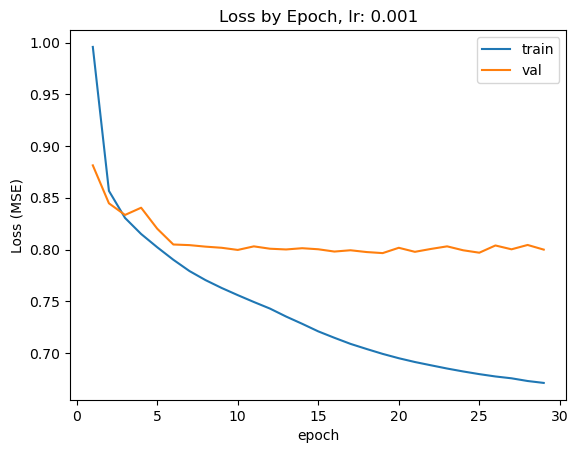

In [33]:
ax = pd.DataFrame(history).drop(columns='total').plot(x='epoch')
ax.set_title(f'Loss by Epoch, lr: {lr}')
ax.set_ylabel('Loss (MSE)')  
plt.show()

In [ ]:
# load weights
model.load_state_dict(best_weights)
model.eval()

# prepare x_test data
X_test_tensor = torch.LongTensor(np.array(X_valid)).to(device)

with torch.no_grad():
    user_ids = X_test_tensor[:, 0]
    item_ids = X_test_tensor[:, 1]
    preds = model(user_ids, item_ids)
    y_pred = preds.cpu().numpy().flatten()

# Compute RMSE
final_loss = np.sqrt(np.mean((np.array(y_pred) - np.array(y_valid)) ** 2))
print(f'Final RMSE: {final_loss:.4f}')


In [ ]:
results_df = X_valid.copy()
results_df['actual_rating'] = y_valid
results_df.rename(columns={'user_id' : 'userId'}, inplace=True)
results_df['predicted_rating'] = y_pred
results_df

## Evaluate

In [58]:
def precision_at_k_df(df, k=10, threshold=2.5):
    user_est_true = defaultdict(list)

    # Collect predictions per user
    for _, row in df.iterrows():
        uid = row['userId']
        pred = row['predicted_rating']
        actual = row['actual_rating']
        user_est_true[uid].append((pred, actual))

    precisions = dict()
    for uid, user_ratings in user_est_true.items():
        # Sort ratings by predicted score
        user_ratings.sort(key=lambda x: x[0], reverse=True)

        # Top-K items
        top_k = user_ratings[:k]

        # Count how many of top-k are relevant
        n_rec_k = sum(est >= threshold for est, _ in top_k)
        n_rel_and_rec_k = sum((est >= threshold and true_r >= threshold) for est, true_r in top_k)

        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0

    return precisions


def recall_at_k_df(df, k=10, threshold=2.5):
    user_est_true = defaultdict(list)

    # Collect predictions per user
    for _, row in df.iterrows():
        uid = row['userId']
        pred = row['predicted_rating']
        actual = row['actual_rating']
        user_est_true[uid].append((pred, actual))

    recalls = dict()
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        top_k = user_ratings[:k]

        n_rel = sum(true_r >= threshold for _, true_r in user_ratings)
        n_rel_and_rec_k = sum((est >= threshold and true_r >= threshold) for est, true_r in top_k)

        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0

    return recalls


def ndcg_at_k(predictions_df, k=10):
    ndcg_results = []

    # Group predictions by user
    grouped = predictions_df.groupby('userId')

    for user_id, group in grouped:
        # sort
        group_sorted = group.sort_values('predicted_rating', ascending=False)

        true_relevance = np.expand_dims(group_sorted['actual_rating'].values, axis=0)
        predicted_scores = np.expand_dims(group_sorted['predicted_rating'].values, axis=0)

        if len(group_sorted) >= k:
            ndcg = ndcg_score(true_relevance, predicted_scores, k=k)
            ndcg_results.append(ndcg)

    mean_ndcg = np.mean(ndcg_results[k])
    return mean_ndcg


def prediction_metrics(predictions_df):
    # precision @k 
    precisions = precision_at_k_df(predictions_df, k=10, threshold=3)
    prec_at_k = sum(prec for prec in precisions.values()) / len(precisions)
    print(f"precision at 10: {prec_at_k}")

    precisions = precision_at_k_df(predictions_df, k=100, threshold=3)
    prec_at_k = sum(prec for prec in precisions.values()) / len(precisions)
    print(f"precision at 100: {prec_at_k}")

    # recall
    recalls = recall_at_k_df(predictions_df, k=10, threshold=3)
    rec_at_k = sum(rec for rec in recalls.values()) / len(recalls)
    print(f"recall at 10: {rec_at_k}")

    recalls = recall_at_k_df(predictions_df, k=100, threshold=3)
    rec_at_k = sum(rec for rec in recalls.values()) / len(recalls)
    print(f"recall at 100: {rec_at_k}")

    # ndcg
    ndcg = ndcg_at_k(predictions_df, k=10)
    print(f"NDCG@10: {ndcg}")

    ndcg = ndcg_at_k(predictions_df, k=100)
    print(f"NDCG@100: {ndcg}")


In [38]:
prediction_metrics(results_df)

precision at 10: 0.9344349542842466
precision at 100: 0.9075656748352172
recall at 10: 0.558099542691041
recall at 100: 0.8843699241524972
NDCG@10: 0.97248852921274
NDCG@100: 0.9446910363671044


## Recommend top 10 movies

In [91]:
def recommend_top_k(model, movie_id_name_df, user_id, all_movie_ids, known_movies, k=10, device='cpu'):
    user_tensor = torch.LongTensor([user_id] * len(all_movie_ids)).to(device)
    movie_tensor = torch.LongTensor(all_movie_ids).to(device)

    model.eval()
    with torch.no_grad():
        preds = model(user_tensor, movie_tensor).cpu().numpy()

    movie_scores = list(zip(all_movie_ids, preds))
    ranked = sorted(movie_scores, key=lambda x: x[1], reverse=True)

    recommended = [(movie, score) for movie, score in ranked if movie not in known_movies][:k]
    scores_df = pd.DataFrame(recommended, columns=['movie_id', 'score'])

    results = pd.merge(scores_df, movie_id_name_df, on='movie_id', how='left')
    return results

# INPUT USER ID
user_id = 1
############

all_movie_ids = list(range(num_movies))
user_ground_truth = X[(X['user_id'] == user_id)]['movie_id'].tolist()
recommend_top_k(model, movies_df, user_id, all_movie_ids, known_movies=user_ground_truth, k=10, device=device)


# Model with additional inputs


In [197]:
class MovieLensDataset(Dataset):
    def __init__(self, df, ratings, genre_feature_cols):
        self.user_ids = df['user_id'].values
        self.age_ids = df['age'].values
        self.gender_ids = df['gender'].values
        self.occupation_ids = df['occupation'].values
        self.movie_ids = df['movie_id'].values

        # Store genre vectors as a tensor
        self.genre_vecs = torch.tensor(df[genre_feature_cols].values, dtype=torch.float)

        self.ratings = ratings.values

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.user_ids[idx], dtype=torch.long),
            torch.tensor(self.age_ids[idx], dtype=torch.long),
            torch.tensor(self.gender_ids[idx], dtype=torch.long),
            torch.tensor(self.occupation_ids[idx], dtype=torch.long),
            torch.tensor(self.movie_ids[idx], dtype=torch.long),
            self.genre_vecs[idx],  # already float tensor
            torch.tensor(self.ratings[idx], dtype=torch.float)
        )


In [198]:
# parse genres into lists
movies_df['genre_list'] = movies_df['genres'].str.split('|')

# encode genres
mlb = MultiLabelBinarizer()
genre_onehots = mlb.fit_transform(movies_df['genre_list'])
genre_cols = mlb.classes_

# clean genre name 
def clean_genre_name(name):
    return name.lower().replace("'", "")  # remove apostrophes and lowercase

cleaned_genre_cols = [clean_genre_name(col) for col in genre_cols]

# attached encoding of genres
genre_df = pd.DataFrame(genre_onehots, columns=cleaned_genre_cols)
movies_with_genres = pd.concat([movies_df[['movie_id']], genre_df], axis=1)


In [199]:
ratings_df = ratings_df.merge(movies_with_genres, on='movie_id', how='left')
ratings_df = ratings_df.merge(users_df, on ='user_id',how='left')
ratings_df.rename(columns={"Children's": 'childrens'}, inplace=True)

# 0 index
ratings_df['movie_id'] = ratings_df['movie_id'] - 1

#cast to correct type for gender
ratings_df['gender'] = ratings_df['gender'].map({'F': 0, 'M': 1}).astype(int)

# label encode
for col in ['age', 'occupation', 'movie_id','user_id']:
    le = LabelEncoder()
    ratings_df[col] = le.fit_transform(ratings_df[col])

X = ratings_df[['user_id', 'movie_id', 'action', 'adventure',
       'animation', 'childrens', 'comedy', 'crime', 'documentary', 'drama',
       'fantasy', 'film-noir', 'horror', 'musical', 'mystery', 'romance',
       'sci-fi', 'thriller', 'war', 'western', 'gender', 'age', 'occupation']]
y = ratings_df['rating'].astype(np.float32)

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=1)

In [227]:
bs = 200

train_loader = DataLoader(MovieLensDataset(X_train, y_train, cleaned_genre_cols), batch_size=bs, shuffle=True)
valid_loader = DataLoader(MovieLensDataset(X_valid, y_valid, cleaned_genre_cols), batch_size=bs, shuffle=False)

dataloaders = {'train': train_loader, 'val': valid_loader}
dataset_sizes = {'train': len(X_train), 'val': len(X_valid)}

## The Model

In [208]:

class UserTower(nn.Module):
    def __init__(self, num_users, num_ages, num_genders, num_occupations, embedding_dim):
        super().__init__()
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.age_embedding = nn.Embedding(num_ages, embedding_dim)
        self.gender_embedding = nn.Embedding(num_genders, embedding_dim)
        self.occupation_embedding = nn.Embedding(num_occupations, embedding_dim)

        self.user_mlp = nn.Sequential(
            nn.Linear(embedding_dim * 4, embedding_dim),
            nn.ReLU(),
            nn.Linear(embedding_dim, embedding_dim)
        )

    def forward(self, user_ids, age_ids, gender_ids, occupation_ids):
        user_emb = self.user_embedding(user_ids)
        age_emb = self.age_embedding(age_ids)
        gender_emb = self.gender_embedding(gender_ids)
        occ_emb = self.occupation_embedding(occupation_ids)

        concat = torch.cat([user_emb, age_emb, gender_emb, occ_emb], dim=1)
        return self.user_mlp(concat)


class ItemTower(nn.Module):
    def __init__(self, num_items, genre_input_dim, embedding_dim):
        super().__init__()
        self.item_embedding = nn.Embedding(num_items, embedding_dim)

        self.genre_linear = nn.Linear(genre_input_dim, embedding_dim)

        self.item_mlp = nn.Sequential(
            nn.Linear(embedding_dim * 2, embedding_dim),
            nn.ReLU(),
            nn.Linear(embedding_dim, embedding_dim)
        )

    def forward(self, item_ids, genre_vecs):
        item_emb = self.item_embedding(item_ids)         # (B, D)
        genre_emb = self.genre_linear(genre_vecs)         # (B, D)
        concat = torch.cat([item_emb, genre_emb], dim=1)  # (B, 2D)
        return self.item_mlp(concat)


class TwoTowerModel(nn.Module):
    def __init__(self, num_users, num_ages, num_genders, num_occupations,
                 num_items, num_genres, embedding_dim):
        super().__init__()
        self.user_tower = UserTower(num_users, num_ages, num_genders, num_occupations, embedding_dim)
        self.item_tower = ItemTower(num_items, num_genres, embedding_dim)

    def forward(self, user_ids, age_ids, gender_ids, occupation_ids, item_ids, genre_ids):
        user_vec = self.user_tower(user_ids, age_ids, gender_ids, occupation_ids)
        item_vec = self.item_tower(item_ids, genre_ids)
        return (user_vec * item_vec).sum(dim=1)

    def get_user_embedding(self, user_ids, age_ids, gender_ids, occupation_ids):
        return self.user_tower(user_ids, age_ids, gender_ids, occupation_ids)

    def get_item_embedding(self, item_ids, genre_ids):
        return self.item_tower(item_ids, genre_ids)


## Training

In [229]:
# model set up
num_users = ratings_df['user_id'].nunique()
num_ages = ratings_df['age'].nunique()
num_genders = ratings_df['gender'].nunique()
num_occupations = ratings_df['occupation'].nunique()
num_movies = movies_df['movie_id'].nunique()

num_genres = len(cleaned_genre_cols)  

embedding_dim = 64
model = TwoTowerModel(
    num_users=num_users,
    num_ages=num_ages,
    num_genders=num_genders,
    num_occupations=num_occupations,
    num_items=num_movies,
    num_genres=num_genres,
    embedding_dim=embedding_dim
)

##### HYPERPARAM ########
lr = 1e-3
wd = 1e-5
n_epochs = 200
patience = 10
#######################

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

criterion = nn.MSELoss(reduction='sum')
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)

# --- Training Loop ---
no_improvements = 0
best_loss = float('inf')
best_weights = None
history = []

for epoch in range(n_epochs):
    stats = {'epoch': epoch + 1, 'total': n_epochs}

    for phase in ('train', 'val'):
        training = (phase == 'train')
        model.train() if training else model.eval()

        running_loss = 0.0

        for batch in dataloaders[phase]:
            user_ids, age_ids, gender_ids, occupation_ids, item_ids, genre_ids, ratings = [x.to(device) for x in batch]
            
            optimizer.zero_grad()
            with torch.set_grad_enabled(training):
                preds = model(user_ids, age_ids, gender_ids, occupation_ids, item_ids, genre_ids)
                loss = criterion(preds, ratings.float())
                if training:
                    loss.backward()
                    optimizer.step()
            running_loss += loss.item()

        epoch_loss = running_loss / dataset_sizes[phase]
        stats[phase] = epoch_loss

        if phase == 'val':
            if epoch_loss < best_loss:
                best_loss = epoch_loss
                best_weights = copy.deepcopy(model.state_dict())
                no_improvements = 0
            else:
                no_improvements += 1

    history.append(stats)
    print('[{epoch:03d}/{total:03d}] train: {train:.4f}, val: {val:.4f}'.format(**stats))

    if no_improvements >= patience:
        print(f'Early stopping on epoch {epoch + 1}')
        break

# load model
model.load_state_dict(best_weights)


[001/200] train: 0.9697, val: 0.8767
[002/200] train: 0.8515, val: 0.8404
[003/200] train: 0.8238, val: 0.8442
[004/200] train: 0.8042, val: 0.8151
[005/200] train: 0.7892, val: 0.8022
[006/200] train: 0.7751, val: 0.7950
[007/200] train: 0.7637, val: 0.7895
[008/200] train: 0.7552, val: 0.7879
[009/200] train: 0.7475, val: 0.7799
[010/200] train: 0.7418, val: 0.7786
[011/200] train: 0.7372, val: 0.7797
[012/200] train: 0.7332, val: 0.7750
[013/200] train: 0.7301, val: 0.7821
[014/200] train: 0.7267, val: 0.7736
[015/200] train: 0.7250, val: 0.7738
[016/200] train: 0.7226, val: 0.7767
[017/200] train: 0.7210, val: 0.7731
[018/200] train: 0.7189, val: 0.7702
[019/200] train: 0.7175, val: 0.7780
[020/200] train: 0.7161, val: 0.7732
[021/200] train: 0.7149, val: 0.7728
[022/200] train: 0.7131, val: 0.7758
[023/200] train: 0.7120, val: 0.7725
[024/200] train: 0.7105, val: 0.7828
[025/200] train: 0.7097, val: 0.7706
[026/200] train: 0.7086, val: 0.7713
[027/200] train: 0.7074, val: 0.7724
[

<All keys matched successfully>

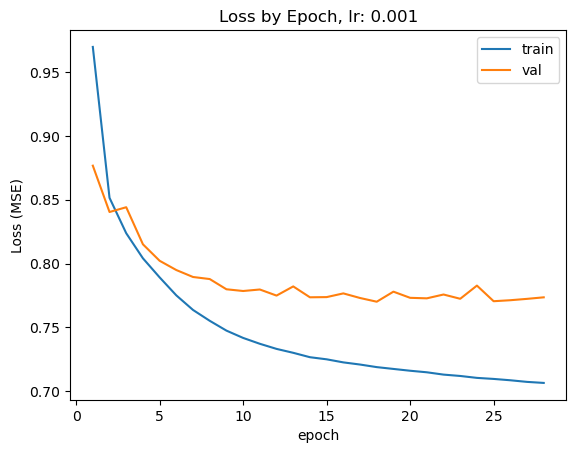

In [231]:
ax = pd.DataFrame(history).drop(columns='total').plot(x='epoch')
ax.set_title(f'Loss by Epoch, lr: {lr}')
ax.set_ylabel('Loss (MSE)')  
plt.show()

## Metrics and Evaluation

In [235]:
# Load best weights and set model to eval mode
model.load_state_dict(best_weights)
model.eval()

# Prepare test tensors (assuming X_valid is a DataFrame or similar)
# Make sure X_valid contains all needed columns
user_ids = torch.LongTensor(X_valid['user_id'].values).to(device)
age_ids = torch.LongTensor(X_valid['age'].values).to(device)
gender_ids = torch.LongTensor(X_valid['gender'].values).to(device)
occupation_ids = torch.LongTensor(X_valid['occupation'].values).to(device)
item_ids = torch.LongTensor(X_valid['movie_id'].values).to(device)

# Assuming genre features are in separate columns in X_valid, e.g. genre_cols
genre_cols =['action', 'adventure',
       'animation', 'childrens', 'comedy', 'crime', 'documentary', 'drama',
       'fantasy', 'film-noir', 'horror', 'musical', 'mystery', 'romance',
       'sci-fi', 'thriller', 'war', 'western']
genre_features = torch.tensor(X_valid[genre_cols].values, dtype=torch.float).to(device)

with torch.no_grad():
    preds = model(user_ids, age_ids, gender_ids, occupation_ids, item_ids, genre_features)
    y_pred = preds.cpu().numpy().flatten()

# Compute RMSE against true ratings
final_loss = np.sqrt(np.mean((y_pred - y_valid.values) ** 2))
print(f'Final RMSE: {final_loss:.4f}')



Final RMSE: 0.8776


In [237]:
results_df = X_valid.copy()
results_df['actual_rating'] = y_valid
results_df.rename(columns={'user_id' : 'userId'}, inplace=True)
results_df['predicted_rating'] = y_pred
results_df

,userId,movie_id,action,adventure,animation,childrens,comedy,crime,documentary,drama,...,romance,sci-fi,thriller,war,western,gender,age,occupation,actual_rating,predicted_rating
630120,3808,2716,1,0,0,0,1,0,0,0,...,0,0,0,0,0,1,3,6,4.0,3.689227
229398,1388,1777,0,0,0,0,0,0,0,1,...,0,0,0,0,0,1,2,17,4.0,3.716250
758377,4509,1366,1,0,0,0,0,0,0,0,...,1,0,1,0,0,1,4,7,2.0,2.003229
159240,1016,3595,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,3,0,3.0,2.711357
254252,1545,1319,0,0,0,0,0,0,0,0,...,0,0,1,0,0,1,2,4,3.0,3.063791
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
875199,5282,2483,0,0,1,1,0,0,0,0,...,0,0,0,0,0,1,1,2,5.0,3.629307
743921,4446,2005,0,0,0,0,0,0,0,0,...,0,0,1,0,0,1,4,5,4.0,4.136340
527163,3259,1007,0,0,0,0,1,0,0,0,...,0,0,0,0,0,1,2,4,4.0,3.964326
623363,3770,1934,1,1,0,0,0,0,0,0,...,0,0,0,0,0,1,2,1,3.0,3.443154


In [238]:
prediction_metrics(results_df)

precision at 10: 0.9378245319326848
precision at 100: 0.9099867112757375
recall at 10: 0.5597577502756457
recall at 100: 0.8852845542801716
NDCG@10: 0.9660786386522084
NDCG@100: 0.9453198350424604


Results from just the user id embedded:

precision at 10: 0.9344349542842466
precision at 100: 0.9075656748352172
recall at 10: 0.558099542691041
recall at 100: 0.8843699241524972
NDCG@10: 0.97248852921274
NDCG@100: 0.9446910363671044


In [246]:
def recommend_top_k_2(model, movie_id_name_df, user_id, user_info_df, all_movie_ids, movie_genres_df, known_movies, k=10, device='cpu'):
    
    # get user features
    user_row = user_info_df[user_info_df['user_id'] == user_id].iloc[0]
    age_id = user_row['age']
    gender_id = user_row['gender']
    occupation_id = user_row['occupation']

    # repeat user features
    user_ids = torch.LongTensor([user_id] * len(all_movie_ids)).to(device)
    age_ids = torch.LongTensor([age_id] * len(all_movie_ids)).to(device)
    gender_ids = torch.LongTensor([gender_id] * len(all_movie_ids)).to(device)
    occupation_ids = torch.LongTensor([occupation_id] * len(all_movie_ids)).to(device)
    item_ids = torch.LongTensor(all_movie_ids).to(device)

    # get genres
    genre_features = torch.tensor(movie_genres_df.loc[all_movie_ids].values, dtype=torch.float).to(device)

    model.eval()
    with torch.no_grad():
        preds = model(user_ids, age_ids, gender_ids, occupation_ids, item_ids, genre_features).cpu().numpy()

    movie_scores = [(movie_id, score) for movie_id, score in zip(all_movie_ids, preds) if movie_id not in known_movies]
    ranked = sorted(movie_scores, key=lambda x: x[1], reverse=True)

    # take top k scores
    recommended = ranked[:k]

    # return df
    scores_df = pd.DataFrame(recommended, columns=['movie_id', 'score'])
    results = pd.merge(scores_df, movie_id_name_df, on='movie_id', how='left')
    return results


In [247]:
user_id = 1
all_movie_ids = list(range(num_movies))  
user_ground_truth = X[X['user_id'] == user_id]['movie_id'].tolist()

recommendations = recommend_top_k_2(
    model=model,
    movie_id_name_df=movies_df,
    user_id=user_id,
    user_info_df=X[['user_id', 'age', 'gender', 'occupation']].drop_duplicates(),
    all_movie_ids=all_movie_ids,
    movie_genres_df=genre_df, 
    known_movies=user_ground_truth,
    k=10,
    device=device
)

print(recommendations)

   movie_id     score                                              title  \
0      2898  4.766898                              Dark Half, The (1993)   
1      1129  4.734339                        Escape from New York (1981)   
2       584  4.725437  I Don't Want to Talk About It (De eso no se ha...   
3       844  4.671903                       Story of Xinghua, The (1993)   
4       689  4.667249                                                NaN   
5      2557  4.634621            I Stand Alone (Seul contre tous) (1998)   
6      1143  4.600877              Three Lives and Only One Death (1996)   
7      2876  4.561570                                  Thumbelina (1994)   
8      1136  4.526037             Monty Python and the Holy Grail (1974)   
9      1242  4.478010                                       Glory (1989)   

                             genres                             genre_list  
0                    Horror|Mystery                      [Horror, Mystery]  
1  Action